#  nb-07 — Behavioral Prediction Model (Deep Learning)
> **Project:** Customer Profiling and Behavioral Prediction Using ML for Personalized Recommendation Systems  
> **Goal:** Train an MLP neural network to predict customer segment & sentiment from behavioral features  
> **Input:** `enriched_profiles.csv` + `segment_summary.csv` (from nb-06)  
> **Model:** Multi-Layer Perceptron (PyTorch) — dual head (segment + sentiment)  
> **Tracking:** MLflow

In [1]:
import subprocess
subprocess.run(['pip', 'install', 'mlflow', '-q'])

import os, json, warnings, logging
from pathlib import Path
from datetime import datetime

warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO, format='%(asctime)s | %(levelname)s | %(message)s')
log = logging.getLogger(__name__)

import pandas as pd
import numpy as np
import joblib
import mlflow
import mlflow.pytorch

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, accuracy_score
)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau
from tqdm.auto import tqdm

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print('=' * 55)
print('  nb-07 — Behavioral Prediction Model')
print('=' * 55)
print(f'  Device  : {DEVICE}')
print(f'  PyTorch : {torch.__version__}')
print(f'  Started : {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')
print('=' * 55)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 103.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 84.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 57.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 866.2/866.2 kB 45.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 15.8 MB/s eta 0:00:00


2026-04-25 17:07:48,369 | INFO | NumExpr defaulting to 4 threads.


  nb-07 — Behavioral Prediction Model
  Device  : cuda
  PyTorch : 2.10.0+cu128
  Started : 2026-04-25 17:08:28


# Config & Paths

In [2]:
ON_KAGGLE = os.path.exists('/kaggle/input')

SEGMENT_NAMES = {
    0: 'Satisfied Loyal Shoppers',
    1: 'Frustrated Complainers',
    2: 'Neutral Browsers',
    3: 'Impulsive Buyers',
    4: 'Engaged Brand Advocates',
}

SEGMENT_COLORS = {
    0: '#2ecc71',
    1: '#e74c3c',
    2: '#3498db',
    3: '#f39c12',
    4: '#9b59b6',
}

NB06_OUT  = Path('/kaggle/input/notebooks/bennjimatakwa/nb-06-cluster-profiling-behavioral-analysis')
DATA_DIR  = NB06_OUT / 'outputs' / 'profiles'
WORK_DIR  = Path('/kaggle/working')
FIG_DIR   = WORK_DIR / 'outputs' / 'figures'
OUT_DIR   = WORK_DIR / 'outputs' / 'models'
LOG_DIR   = WORK_DIR / 'mlflow_runs'

for d in [FIG_DIR, OUT_DIR, LOG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

CFG = {
    'experiment_name' : '05_Behavioral_Prediction_MLP',
    'run_name'        : f'mlp-v1-{datetime.now().strftime("%Y%m%d_%H%M")}',
    'random_state'    : SEED,
    'test_size'       : 0.15,
    'val_size'        : 0.15,
    'batch_size'      : 512,
    'epochs'          : 50,
    'lr'              : 1e-3,
    'weight_decay'    : 1e-4,
    'patience'        : 7,
    'hidden_dims'     : [256, 128, 64],
    'dropout'         : 0.3,
    'n_segments'      : 5,
    'n_sentiments'    : 3,
}

print('📁 Checking input files:')
files_to_check = [
    (DATA_DIR / 'enriched_profiles.csv', 'enriched_profiles'),
    (DATA_DIR / 'segment_summary.csv',   'segment_summary'),
    (DATA_DIR / 'segment_insights.json', 'segment_insights'),
]
for path, name in files_to_check:
    exists = path.exists()
    mb = path.stat().st_size / 1e6 if exists else 0
    print(f'   {"✅" if exists else "❌"} {name:<30} {mb:.1f} MB')

print(f'\n✅ Config OK')
print(f'   Device     : {DEVICE}')
print(f'   Epochs     : {CFG["epochs"]}')
print(f'   Batch size : {CFG["batch_size"]}')
print(f'   Hidden     : {CFG["hidden_dims"]}')

📁 Checking input files:
   ✅ enriched_profiles              10.1 MB
   ✅ segment_summary                0.0 MB
   ✅ segment_insights               0.0 MB

✅ Config OK
   Device     : cuda
   Epochs     : 50
   Batch size : 512
   Hidden     : [256, 128, 64]


# Data load 

In [3]:
log.info('Loading enriched profiles...')

df = pd.read_csv(DATA_DIR / 'enriched_profiles.csv')

print(f'✅ Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'   Columns: {df.columns.tolist()}')

# ── Encode targets
le_segment  = LabelEncoder()
le_sentiment = LabelEncoder()

df['segment_label']  = le_segment.fit_transform(df['final_cluster'])
df['sentiment_label'] = le_sentiment.fit_transform(df['sentiment'])

print(f'\n── Target encodings ──')
print(f'   Segment  : {dict(zip(le_segment.classes_, le_segment.transform(le_segment.classes_)))}')
print(f'   Sentiment: {dict(zip(le_sentiment.classes_, le_sentiment.transform(le_sentiment.classes_)))}')

# ── Define input features
FEATURE_COLS = [
    'frustration_score', 'engagement_quality',
    'influence_weight',  'recency_weight',
    'word_count',        'has_reply',
    'bilstm_prob_neg',   'bilstm_prob_neu',
    'bilstm_prob_pos',   'bilstm_confidence',
]
FEATURE_COLS = [f for f in FEATURE_COLS if f in df.columns]

print(f'\n── Features selected ──')
print(f'   Total : {len(FEATURE_COLS)}')
for f in FEATURE_COLS:
    print(f'   ✅ {f}')

# ── Drop NaN
df_model = df[FEATURE_COLS + ['segment_label', 'sentiment_label']].dropna()
print(f'\n   Rows after dropna : {len(df_model):,}')

# ── Scale features
scaler   = StandardScaler()
X        = scaler.fit_transform(df_model[FEATURE_COLS].values)
y_seg    = df_model['segment_label'].values
y_sent   = df_model['sentiment_label'].values

joblib.dump(scaler,      OUT_DIR / 'mlp_scaler.pkl')
joblib.dump(le_segment,  OUT_DIR / 'le_segment.pkl')
joblib.dump(le_sentiment,OUT_DIR / 'le_sentiment.pkl')

print(f'\n✅ Feature matrix : {X.shape}')
print(f'   Segment classes : {np.unique(y_seg)}')
print(f'   Sentiment classes: {np.unique(y_sent)}')

# ── Train / Val / Test split
X_temp, X_test, ys_temp, ys_test, yse_temp, yse_test = train_test_split(
    X, y_seg, y_sent,
    test_size    = CFG['test_size'],
    random_state = CFG['random_state'],
    stratify     = y_seg
)
X_train, X_val, ys_train, ys_val, yse_train, yse_val = train_test_split(
    X_temp, ys_temp, yse_temp,
    test_size    = CFG['val_size'] / (1 - CFG['test_size']),
    random_state = CFG['random_state'],
    stratify     = ys_temp
)

print(f'\n── Split sizes ──')
print(f'   Train : {len(X_train):,}')
print(f'   Val   : {len(X_val):,}')
print(f'   Test  : {len(X_test):,}')

2026-04-25 17:08:28,061 | INFO | Loading enriched profiles...


✅ Loaded: 99,999 rows × 15 columns
   Columns: ['appName', 'sentiment', 'score', 'final_cluster', 'segment_name', 'frustration_score', 'engagement_quality', 'influence_weight', 'recency_weight', 'word_count', 'has_reply', 'bilstm_prob_neg', 'bilstm_prob_neu', 'bilstm_prob_pos', 'bilstm_confidence']

── Target encodings ──
   Segment  : {np.int64(0): np.int64(0), np.int64(1): np.int64(1), np.int64(2): np.int64(2), np.int64(3): np.int64(3), np.int64(4): np.int64(4)}
   Sentiment: {'negative': np.int64(0), 'neutral': np.int64(1), 'positive': np.int64(2)}

── Features selected ──
   Total : 10
   ✅ frustration_score
   ✅ engagement_quality
   ✅ influence_weight
   ✅ recency_weight
   ✅ word_count
   ✅ has_reply
   ✅ bilstm_prob_neg
   ✅ bilstm_prob_neu
   ✅ bilstm_prob_pos
   ✅ bilstm_confidence

   Rows after dropna : 99,999

✅ Feature matrix : (99999, 10)
   Segment classes : [0 1 2 3 4]
   Sentiment classes: [0 1 2]

── Split sizes ──
   Train : 69,999
   Val   : 15,000
   Test  : 15,00

# Dataset & Model Definition

In [4]:
# ── PyTorch Dataset
class BehaviorDataset(Dataset):
    def __init__(self, X, y_seg, y_sent):
        self.X      = torch.FloatTensor(X)
        self.y_seg  = torch.LongTensor(y_seg)
        self.y_sent = torch.LongTensor(y_sent)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y_seg[idx], self.y_sent[idx]

# ── DataLoaders
train_loader = DataLoader(
    BehaviorDataset(X_train, ys_train, yse_train),
    batch_size=CFG['batch_size'], shuffle=True,  num_workers=0
)
val_loader = DataLoader(
    BehaviorDataset(X_val, ys_val, yse_val),
    batch_size=CFG['batch_size'], shuffle=False, num_workers=0
)
test_loader = DataLoader(
    BehaviorDataset(X_test, ys_test, yse_test),
    batch_size=CFG['batch_size'], shuffle=False, num_workers=0
)

# ── Dual-Head MLP Model
class BehaviorMLP(nn.Module):
    def __init__(self, input_dim, hidden_dims, n_segments, n_sentiments, dropout):
        super().__init__()

        # ── Shared backbone
        layers = []
        in_dim = input_dim
        for h in hidden_dims:
            layers += [
                nn.Linear(in_dim, h),
                nn.BatchNorm1d(h),
                nn.ReLU(),
                nn.Dropout(dropout),
            ]
            in_dim = h
        self.backbone = nn.Sequential(*layers)

        # ── Task heads
        self.segment_head  = nn.Linear(in_dim, n_segments)
        self.sentiment_head = nn.Linear(in_dim, n_sentiments)

    def forward(self, x):
        shared = self.backbone(x)
        return self.segment_head(shared), self.sentiment_head(shared)

# ── Instantiate model
model = BehaviorMLP(
    input_dim    = len(FEATURE_COLS),
    hidden_dims  = CFG['hidden_dims'],
    n_segments   = CFG['n_segments'],
    n_sentiments = CFG['n_sentiments'],
    dropout      = CFG['dropout'],
).to(DEVICE)

# ── Loss & optimizer
criterion_seg  = nn.CrossEntropyLoss()
criterion_sent = nn.CrossEntropyLoss()
optimizer      = optim.AdamW(
    model.parameters(),
    lr           = CFG['lr'],
    weight_decay = CFG['weight_decay']
)
scheduler = ReduceLROnPlateau(
    optimizer, mode='min', patience=3, factor=0.5
)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'✅ Model ready:')
print(f'   Input dim    : {len(FEATURE_COLS)}')
print(f'   Hidden dims  : {CFG["hidden_dims"]}')
print(f'   Total params : {total_params:,}')
print(f'   Device       : {DEVICE}')
print(f'\n{model}')

✅ Model ready:
   Input dim    : 10
   Hidden dims  : [256, 128, 64]
   Total params : 45,384
   Device       : cuda

BehaviorMLP(
  (backbone): Sequential(
    (0): Linear(in_features=10, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
  )
  (segment_head): Linear(in_features=64, out_features=5, bias=True)
  (sentiment_head): Linear(in_features=64, out_features=3, bias=True)
)


# Training Loop 

2026-04-25 17:08:29,076 | INFO | Starting training...


  Epoch   1/50 | Loss 1.8028/1.5131 | SegAcc 0.472/0.518 | SentAcc 0.775/0.844 ✅ best
  Epoch   5/50 | Loss 1.4562/1.3730 | SegAcc 0.515/0.536 | SentAcc 0.868/0.878 ✅ best
  Epoch  10/50 | Loss 1.4108/1.3508 | SegAcc 0.528/0.542 | SentAcc 0.873/0.881 ✅ best
  Epoch  15/50 | Loss 1.3914/1.3424 | SegAcc 0.534/0.545 | SentAcc 0.877/0.882 ✅ best
  Epoch  20/50 | Loss 1.3840/1.3350 | SegAcc 0.535/0.549 | SentAcc 0.877/0.881 ✅ best
  Epoch  25/50 | Loss 1.3731/1.3325 | SegAcc 0.539/0.546 | SentAcc 0.878/0.881
  Epoch  30/50 | Loss 1.3648/1.3238 | SegAcc 0.543/0.550 | SentAcc 0.879/0.883 ✅ best
  Epoch  35/50 | Loss 1.3636/1.3243 | SegAcc 0.544/0.550 | SentAcc 0.879/0.882
  Epoch  40/50 | Loss 1.3607/1.3219 | SegAcc 0.543/0.550 | SentAcc 0.879/0.883 ✅ best
  Epoch  45/50 | Loss 1.3580/1.3205 | SegAcc 0.545/0.550 | SentAcc 0.879/0.883 ✅ best
  Epoch  50/50 | Loss 1.3564/1.3197 | SegAcc 0.547/0.551 | SentAcc 0.879/0.882

✅ Training complete!
   Best epoch    : 49
   Best val loss : 1.3194


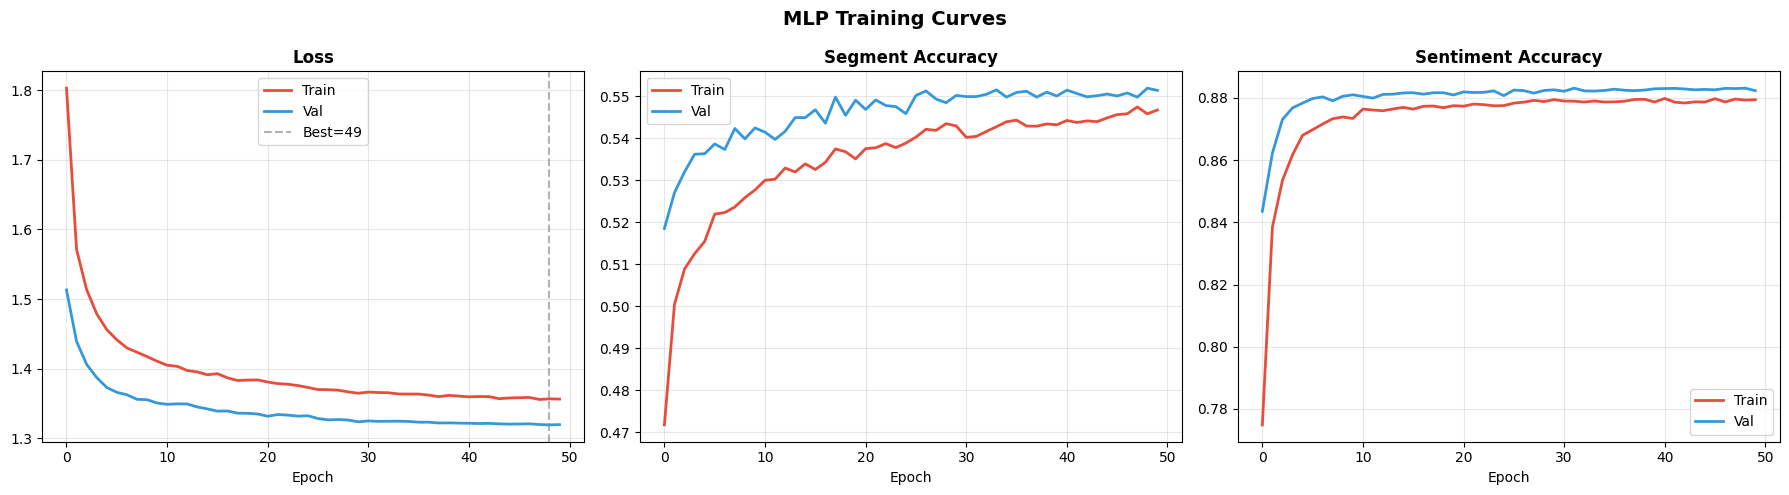

In [5]:
log.info('Starting training...')

history = {
    'train_loss': [], 'val_loss': [],
    'train_seg_acc': [], 'val_seg_acc': [],
    'train_sent_acc': [], 'val_sent_acc': [],
}

best_val_loss  = float('inf')
patience_count = 0
best_epoch     = 0

for epoch in range(CFG['epochs']):
    # ── TRAIN
    model.train()
    train_loss = 0.0
    train_seg_correct  = 0
    train_sent_correct = 0
    train_total        = 0

    for X_batch, y_seg_batch, y_sent_batch in train_loader:
        X_batch      = X_batch.to(DEVICE)
        y_seg_batch  = y_seg_batch.to(DEVICE)
        y_sent_batch = y_sent_batch.to(DEVICE)

        optimizer.zero_grad()
        seg_logits, sent_logits = model(X_batch)

        loss_seg  = criterion_seg(seg_logits, y_seg_batch)
        loss_sent = criterion_sent(sent_logits, y_sent_batch)
        loss      = loss_seg + loss_sent

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        train_loss         += loss.item() * len(X_batch)
        train_seg_correct  += (seg_logits.argmax(1) == y_seg_batch).sum().item()
        train_sent_correct += (sent_logits.argmax(1) == y_sent_batch).sum().item()
        train_total        += len(X_batch)

    train_loss     /= train_total
    train_seg_acc   = train_seg_correct  / train_total
    train_sent_acc  = train_sent_correct / train_total

    # ── VALIDATE
    model.eval()
    val_loss = 0.0
    val_seg_correct  = 0
    val_sent_correct = 0
    val_total        = 0

    with torch.no_grad():
        for X_batch, y_seg_batch, y_sent_batch in val_loader:
            X_batch      = X_batch.to(DEVICE)
            y_seg_batch  = y_seg_batch.to(DEVICE)
            y_sent_batch = y_sent_batch.to(DEVICE)

            seg_logits, sent_logits = model(X_batch)
            loss_seg  = criterion_seg(seg_logits, y_seg_batch)
            loss_sent = criterion_sent(sent_logits, y_sent_batch)
            loss      = loss_seg + loss_sent

            val_loss         += loss.item() * len(X_batch)
            val_seg_correct  += (seg_logits.argmax(1) == y_seg_batch).sum().item()
            val_sent_correct += (sent_logits.argmax(1) == y_sent_batch).sum().item()
            val_total        += len(X_batch)

    val_loss     /= val_total
    val_seg_acc   = val_seg_correct  / val_total
    val_sent_acc  = val_sent_correct / val_total

    scheduler.step(val_loss)

    # ── Record history
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_seg_acc'].append(train_seg_acc)
    history['val_seg_acc'].append(val_seg_acc)
    history['train_sent_acc'].append(train_sent_acc)
    history['val_sent_acc'].append(val_sent_acc)

    # ── Early stopping
    if val_loss < best_val_loss:
        best_val_loss  = val_loss
        best_epoch     = epoch + 1
        patience_count = 0
        torch.save(model.state_dict(), OUT_DIR / 'mlp_best.pt')
    else:
        patience_count += 1

    # ── Print every 5 epochs
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f'  Epoch {epoch+1:>3}/{CFG["epochs"]} | '
              f'Loss {train_loss:.4f}/{val_loss:.4f} | '
              f'SegAcc {train_seg_acc:.3f}/{val_seg_acc:.3f} | '
              f'SentAcc {train_sent_acc:.3f}/{val_sent_acc:.3f}'
              + (' ✅ best' if patience_count == 0 else ''))

    if patience_count >= CFG['patience']:
        print(f'\n⏹ Early stopping at epoch {epoch+1}')
        break

print(f'\n✅ Training complete!')
print(f'   Best epoch    : {best_epoch}')
print(f'   Best val loss : {best_val_loss:.4f}')

# ── Plot training curves
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('MLP Training Curves', fontweight='bold', fontsize=14)

axes[0].plot(history['train_loss'], label='Train', color='#e74c3c', linewidth=2)
axes[0].plot(history['val_loss'],   label='Val',   color='#3498db', linewidth=2)
axes[0].axvline(best_epoch - 1, color='gray', linestyle='--', alpha=0.6, label=f'Best={best_epoch}')
axes[0].set_title('Loss', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history['train_seg_acc'], label='Train', color='#e74c3c', linewidth=2)
axes[1].plot(history['val_seg_acc'],   label='Val',   color='#3498db', linewidth=2)
axes[1].set_title('Segment Accuracy', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(history['train_sent_acc'], label='Train', color='#e74c3c', linewidth=2)
axes[2].plot(history['val_sent_acc'],   label='Val',   color='#3498db', linewidth=2)
axes[2].set_title('Sentiment Accuracy', fontweight='bold')
axes[2].set_xlabel('Epoch')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / '07_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# Evaluation & confusion 

2026-04-25 17:09:24,670 | INFO | Evaluating on test set...


  TEST SET EVALUATION
  Segment  Accuracy : 0.5517
  Segment  F1 (w)   : 0.5531
  Sentiment Accuracy : 0.8813
  Sentiment F1 (w)   : 0.8831

── Segment Classification Report ──
                          precision    recall  f1-score   support

Satisfied Loyal Shoppers       0.67      0.61      0.64      3143
  Frustrated Complainers       0.65      0.49      0.56      3278
        Neutral Browsers       0.44      0.43      0.43      2743
        Impulsive Buyers       0.45      0.68      0.55      3102
 Engaged Brand Advocates       0.63      0.54      0.58      2734

                accuracy                           0.55     15000
               macro avg       0.57      0.55      0.55     15000
            weighted avg       0.57      0.55      0.55     15000


── Sentiment Classification Report ──
              precision    recall  f1-score   support

    negative       1.00      0.92      0.96      5035
     neutral       0.80      0.87      0.83      4977
    positive       0.86 

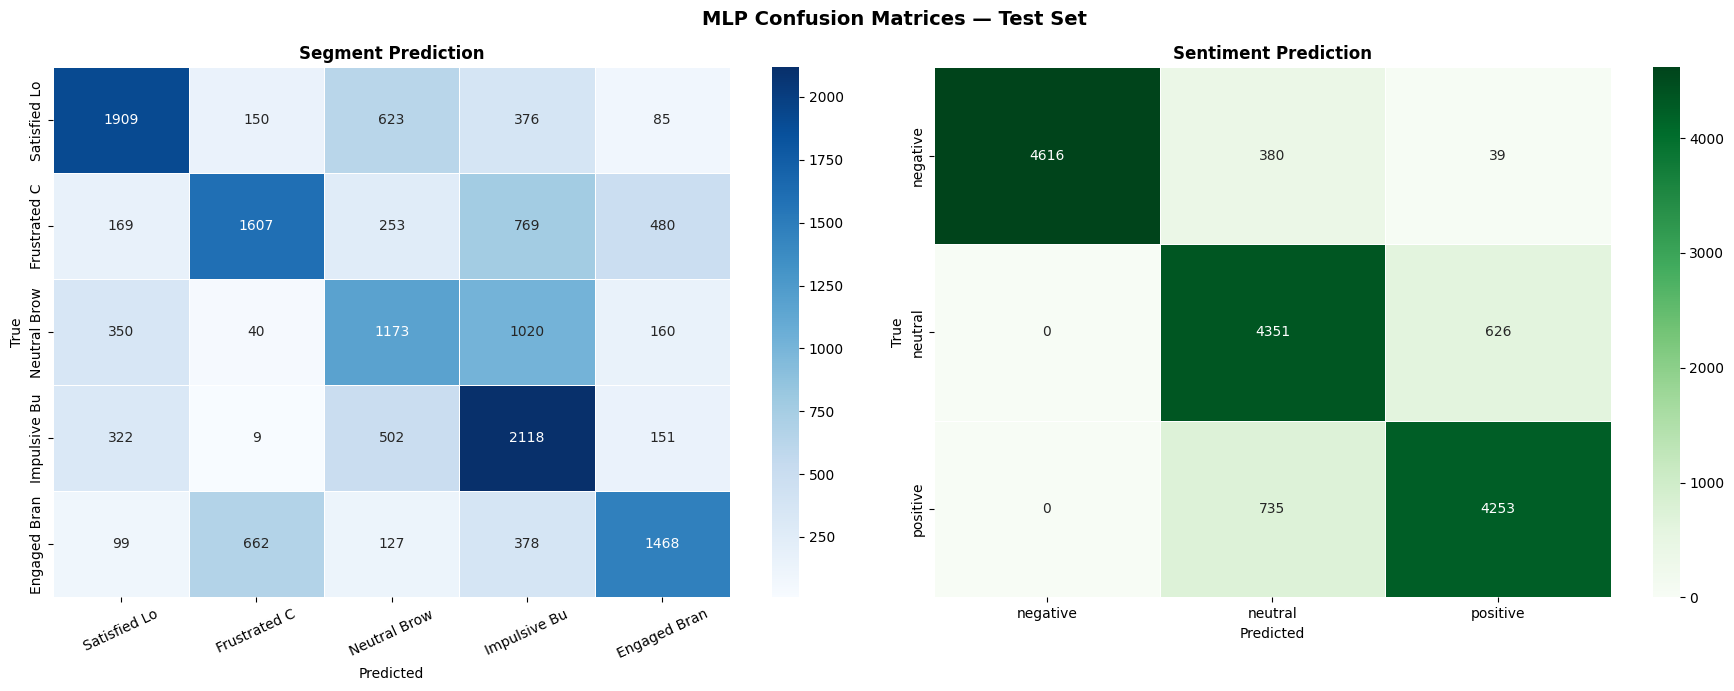

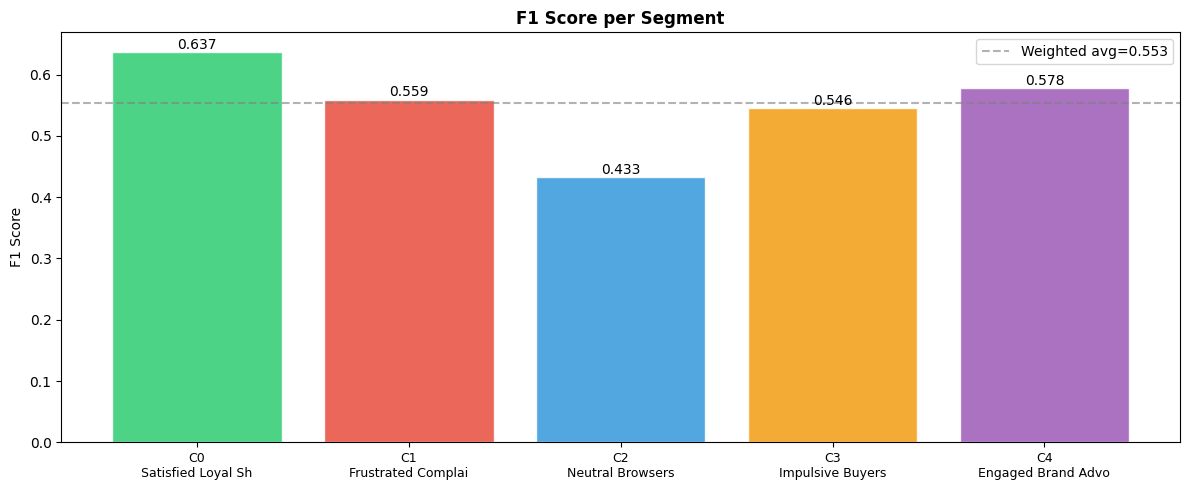

In [6]:
log.info('Evaluating on test set...')

# ── Load best model
model.load_state_dict(torch.load(OUT_DIR / 'mlp_best.pt', map_location=DEVICE))
model.eval()

all_seg_pred  = []
all_sent_pred = []
all_seg_true  = []
all_sent_true = []

with torch.no_grad():
    for X_batch, y_seg_batch, y_sent_batch in test_loader:
        X_batch = X_batch.to(DEVICE)
        seg_logits, sent_logits = model(X_batch)

        all_seg_pred.extend(seg_logits.argmax(1).cpu().numpy())
        all_sent_pred.extend(sent_logits.argmax(1).cpu().numpy())
        all_seg_true.extend(y_seg_batch.numpy())
        all_sent_true.extend(y_sent_batch.numpy())

all_seg_pred  = np.array(all_seg_pred)
all_sent_pred = np.array(all_sent_pred)
all_seg_true  = np.array(all_seg_true)
all_sent_true = np.array(all_sent_true)

# ── Metrics
seg_acc   = accuracy_score(all_seg_true, all_seg_pred)
sent_acc  = accuracy_score(all_sent_true, all_sent_pred)
seg_f1    = f1_score(all_seg_true, all_seg_pred, average='weighted')
sent_f1   = f1_score(all_sent_true, all_sent_pred, average='weighted')

print('=' * 55)
print('  TEST SET EVALUATION')
print('=' * 55)
print(f'  Segment  Accuracy : {seg_acc:.4f}')
print(f'  Segment  F1 (w)   : {seg_f1:.4f}')
print(f'  Sentiment Accuracy : {sent_acc:.4f}')
print(f'  Sentiment F1 (w)   : {sent_f1:.4f}')
print('=' * 55)

# ── Classification reports
seg_names  = [SEGMENT_NAMES[i] for i in range(CFG['n_segments'])]
sent_names = list(le_sentiment.classes_)

print('\n── Segment Classification Report ──')
print(classification_report(all_seg_true, all_seg_pred,
                             target_names=seg_names))

print('\n── Sentiment Classification Report ──')
print(classification_report(all_sent_true, all_sent_pred,
                             target_names=sent_names))

# ── Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('MLP Confusion Matrices — Test Set',
             fontweight='bold', fontsize=14)

# Segment
cm_seg = confusion_matrix(all_seg_true, all_seg_pred)
sns.heatmap(
    cm_seg, annot=True, fmt='d',
    cmap='Blues', linewidths=0.5,
    xticklabels=[s[:12] for s in seg_names],
    yticklabels=[s[:12] for s in seg_names],
    ax=axes[0]
)
axes[0].set_title('Segment Prediction', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].tick_params(axis='x', rotation=25)

# Sentiment
cm_sent = confusion_matrix(all_sent_true, all_sent_pred)
sns.heatmap(
    cm_sent, annot=True, fmt='d',
    cmap='Greens', linewidths=0.5,
    xticklabels=sent_names,
    yticklabels=sent_names,
    ax=axes[1]
)
axes[1].set_title('Sentiment Prediction', fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

plt.tight_layout()
plt.savefig(FIG_DIR / '07_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Per-segment F1 bar chart
seg_f1_per_class = f1_score(all_seg_true, all_seg_pred, average=None)
fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(
    range(CFG['n_segments']), seg_f1_per_class,
    color=[SEGMENT_COLORS[k] for k in range(CFG['n_segments'])],
    edgecolor='white', alpha=0.85
)
ax.set_xticks(range(CFG['n_segments']))
ax.set_xticklabels([f'C{k}\n{SEGMENT_NAMES[k][:18]}' for k in range(CFG['n_segments'])],
                    fontsize=9)
ax.set_title('F1 Score per Segment', fontweight='bold')
ax.set_ylabel('F1 Score')
ax.axhline(seg_f1, color='gray', linestyle='--', alpha=0.6, label=f'Weighted avg={seg_f1:.3f}')
ax.legend()
for bar, v in zip(bars, seg_f1_per_class):
    ax.text(bar.get_x() + bar.get_width()/2,
            v + 0.005, f'{v:.3f}', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig(FIG_DIR / '07_segment_f1.png', dpi=150, bbox_inches='tight')
plt.show()

# MLflow logging & Save 


In [7]:
log.info('Logging to MLflow...')

mlflow.set_tracking_uri(str(LOG_DIR))
mlflow.set_experiment(CFG['experiment_name'])

with mlflow.start_run(run_name=CFG['run_name']) as run:
    RUN_ID = run.info.run_id

    # ── Parameters
    mlflow.log_params({
        'input_dim'     : len(FEATURE_COLS),
        'hidden_dims'   : str(CFG['hidden_dims']),
        'dropout'       : CFG['dropout'],
        'batch_size'    : CFG['batch_size'],
        'epochs_run'    : best_epoch,
        'lr'            : CFG['lr'],
        'weight_decay'  : CFG['weight_decay'],
        'patience'      : CFG['patience'],
        'n_segments'    : CFG['n_segments'],
        'n_sentiments'  : CFG['n_sentiments'],
        'train_size'    : len(X_train),
        'val_size'      : len(X_val),
        'test_size'     : len(X_test),
        'total_params'  : sum(p.numel() for p in model.parameters()),
    })

    # ── Metrics
    mlflow.log_metrics({
        'test_seg_accuracy'  : round(seg_acc,  4),
        'test_seg_f1'        : round(seg_f1,   4),
        'test_sent_accuracy' : round(sent_acc, 4),
        'test_sent_f1'       : round(sent_f1,  4),
        'best_val_loss'      : round(best_val_loss, 4),
        'best_epoch'         : best_epoch,
    })

    # ── Per-segment F1
    for k, f1_val in enumerate(seg_f1_per_class):
        mlflow.log_metric(f'seg{k}_f1', round(float(f1_val), 4))

    # ── Figures
    for fig_file in FIG_DIR.glob('07_*.png'):
        mlflow.log_artifact(str(fig_file), artifact_path='figures')

    # ── Log model
    mlflow.pytorch.log_model(model, artifact_path='mlp_model')

    # ── Log training history
    mlflow.log_dict(history, 'training_history.json')

print(f'✅ MLflow Run ID: {RUN_ID}')

# ── Save all artifacts
torch.save(model.state_dict(), OUT_DIR / 'mlp_best.pt')
joblib.dump(scaler,       OUT_DIR / 'mlp_scaler.pkl')
joblib.dump(le_segment,   OUT_DIR / 'le_segment.pkl')
joblib.dump(le_sentiment, OUT_DIR / 'le_sentiment.pkl')

# ── Save feature list
with open(OUT_DIR / 'feature_cols.json', 'w') as f:
    json.dump(FEATURE_COLS, f)

# ── Save predictions for nb-08
pred_df = pd.DataFrame({
    'seg_true'    : all_seg_true,
    'seg_pred'    : all_seg_pred,
    'sent_true'   : all_sent_true,
    'sent_pred'   : all_sent_pred,
    'seg_name_true': [SEGMENT_NAMES[i] for i in all_seg_true],
    'seg_name_pred': [SEGMENT_NAMES[i] for i in all_seg_pred],
})
pred_df.to_csv(OUT_DIR / 'test_predictions.csv', index=False)

print('\n✅ Files saved:')
print(f'   mlp_best.pt')
print(f'   mlp_scaler.pkl')
print(f'   le_segment.pkl')
print(f'   le_sentiment.pkl')
print(f'   feature_cols.json')
print(f'   test_predictions.csv')

print('\n' + '=' * 55)
print('  nb-07 Behavioral Prediction COMPLETE')
print('=' * 55)
print(f'  Segment  Accuracy : {seg_acc:.4f}')
print(f'  Segment  F1 (w)   : {seg_f1:.4f}')
print(f'  Sentiment Accuracy : {sent_acc:.4f}')
print(f'  Sentiment F1 (w)   : {sent_f1:.4f}')
print(f'  Best Epoch         : {best_epoch}')
print(f'  Best Val Loss      : {best_val_loss:.4f}')
print(f'  MLflow Run ID      : {RUN_ID}')
print('=' * 55)



2026-04-25 17:09:26,167 | INFO | Logging to MLflow...
2026/04/25 17:09:26 INFO mlflow.tracking.fluent: Experiment with name '05_Behavioral_Prediction_MLP' does not exist. Creating a new experiment.
2026/04/25 17:09:26 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/25 17:09:26 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/04/25 17:09:26 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.10.0' without the local version label to make it installable from PyPI. To specify pip requirements contain

✅ MLflow Run ID: 528fc6ef3857427cad5a9307d2cd0593

✅ Files saved:
   mlp_best.pt
   mlp_scaler.pkl
   le_segment.pkl
   le_sentiment.pkl
   feature_cols.json
   test_predictions.csv

  nb-07 Behavioral Prediction COMPLETE
  Segment  Accuracy : 0.5517
  Segment  F1 (w)   : 0.5531
  Sentiment Accuracy : 0.8813
  Sentiment F1 (w)   : 0.8831
  Best Epoch         : 49
  Best Val Loss      : 1.3194
  MLflow Run ID      : 528fc6ef3857427cad5a9307d2cd0593
